# **HANDS - ON: EXPLORACIÓN DE DATOS**



Una vez visto la presentación ***Exploración de datos***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1hX8uxJp5h03eYrgAnyznp8yeeG2syiD_/view?usp=drive_link)

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1eXIB1nd8aaBZWDYBXlIlfCOVkAe-ETrI?usp=drive_link).

## **ANÁLISIS EXPLORATPRIO**

El **Análisis Exploratorio de Datos (EDA)** es la etapa donde **se descubren patrones, se detectan anomalías y se comprueban hipótesis mediante estadísticas y visualizaciones**. Es el proceso fundamental para entender la salud de la información antes de cualquier toma de decisiones.

A través de herramientas descriptivas y gráficos de dispersión, esta fase permite limpiar inconsistencias y validar la calidad de la muestra. Su ejecución garantiza que las conclusiones posteriores se apoyen en evidencia real, minimizando sesgos y optimizando la precisión de los modelos predictivos.

In [1]:
# Importar librerías

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Importar datos

# En Google Colab se usaría la ruta '/content/youtube_clean.csv'.
# En local leemos el archivo generado en el Hands-On de Limpieza de Datos:
ruta = 'youtube_clean.csv'
df_yt = pd.read_csv(ruta)

df_yt

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación
0,1,título,música,129257,11299,21,8790,127,2024-07-02
1,2,título,películas,247904,15579,211,4775,63,2022-02-13
2,3,sin título,comedia,3073,14780,1095,9847,55,2016-07-06
3,4,título,gaming,268858,2691,4420,7614,78,2017-12-03
4,5,título,gaming,162893,16521,2294,6508,143,2023-11-24
...,...,...,...,...,...,...,...,...,...
303,106,título,películas,150272,11299,4605,6716,213,2021-09-04
304,131,título,tecnología,25407,9999999,2437,4498,137,2025-07-18
305,6,título,películas,42160,10721,3547,9033,58,2025-08-27
306,97,título,deportes,13530,14437,2631,2629,158,2018-03-12


In [3]:
# Ver resumen estadístico de las columnas numéricas

columnas_numericas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']
df_yt[columnas_numericas].describe()

,views,likes,dislikes,comentarios,duración_min
count,308.000000,3.080000e+02,308.000000,308.000000,308.000000
mean,144805.269481,6.265995e+05,12193.288961,5058.188312,139.853896
std,86246.543475,2.407311e+06,52900.153300,2940.396104,139.066834
min,1691.000000,9.700000e+01,21.000000,12.000000,1.000000
25%,74129.500000,5.774250e+03,1523.750000,2667.500000,58.000000
50%,129257.000000,1.129900e+04,2590.000000,4931.500000,123.500000
75%,224050.750000,1.575300e+04,3777.500000,7740.750000,181.500000
max,299408.000000,9.999999e+06,300408.000000,9987.000000,800.000000


### **VALORES ATÍPICOS Y TRATAMIENTO**

**Los valores atípicos son observaciones que se alejan significativamente del resto de los datos**. Pueden ser causados por errores en la entrada de datos o por fenómenos naturales del dataset.

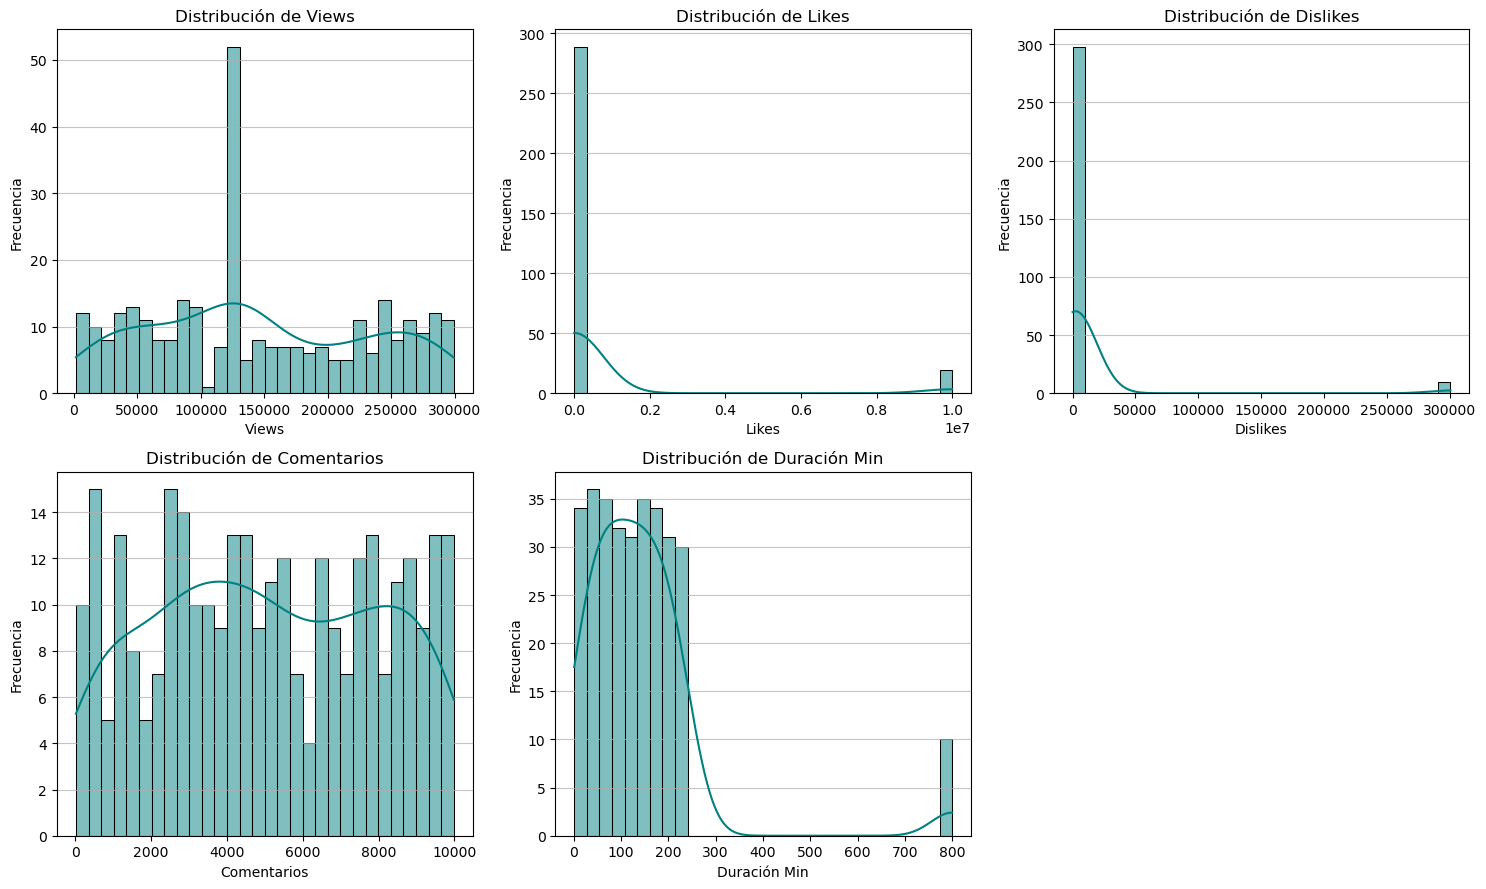

In [4]:
# Observar distribución de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_yt[col], bins=30, kde=True, color='teal')
    plt.title(f'Distribución de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

# Todas las distribuciones no son normales y casi todos tienen valores extremos

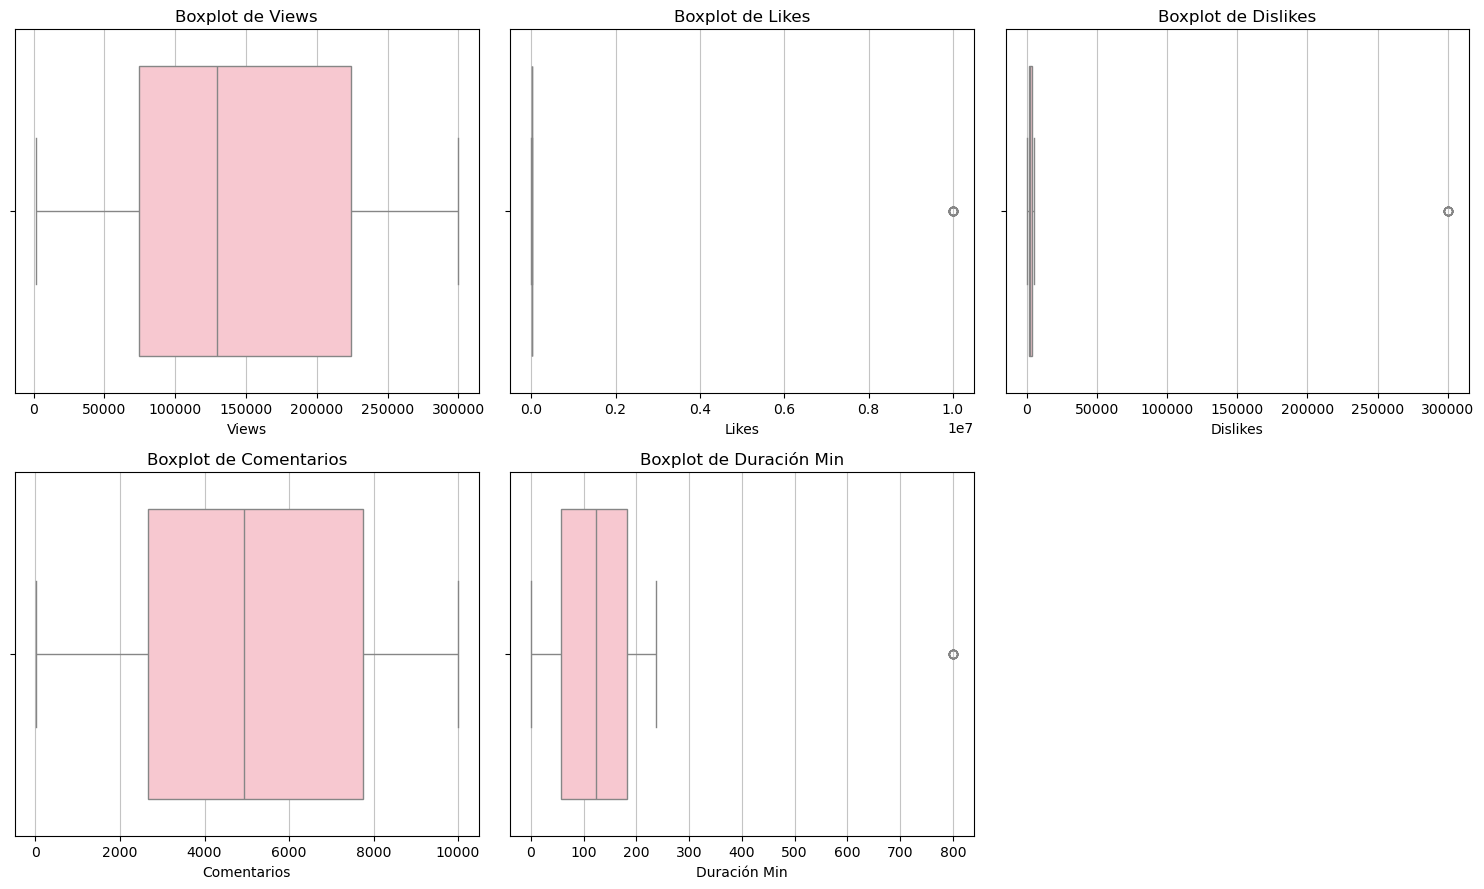

In [5]:
# Observar comportamiento cuartil de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_yt[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

# Tres gráficos de caja presentan valores extremos

#### **RANGO INTERCUARTILICO**

El **Rango Intercuartílico (IQR)** es una medida fundamental de dispersión estadística, utilizada principalmente para detectar y manejar **valores atípicos (outliers)** en un conjunto de datos. Se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1):

$$IQR = Q3 - Q1$$

Para identificar outliers, se definen límites:

*   **Límite Inferior (LI):** $LI = Q1 - 1.5 \times IQR$

*   **Límite Superior (LS):** $LS = Q3 + 1.5 \times IQR$


In [6]:
# Ver cantidad de registros iniciales

print(f"Cantidad de datos iniciales: {len(df_yt)}")

Cantidad de datos iniciales: 308


In [7]:
# Calculo del IQR

df_copy = df_yt.copy() # preservar el dataset haciendo una copia

for col in columnas_numericas:

    Q1 = df_copy[col].quantile(0.25) # Primer cuartil
    Q3 = df_copy[col].quantile(0.75) # Tercer cuartil
    IQR = Q3 - Q1 # Rango Intercuartilico

    lim_inf_iqr = Q1 - 1.5 * IQR # Límite inferior
    lim_sup_iqr = Q3 + 1.5 * IQR # Límite superior

    cant_inicial = len(df_copy)
    # Filtro de los datos dentro de los límites
    df_copy = df_copy[(df_copy[col] >= lim_inf_iqr) & (df_copy[col] <= lim_sup_iqr)]
    cant_final = len(df_copy)

    print(f"Columna '{col}': Se eliminaron {cant_inicial - cant_final} registros.")

Columna 'views': Se eliminaron 0 registros.
Columna 'likes': Se eliminaron 19 registros.
Columna 'dislikes': Se eliminaron 10 registros.
Columna 'comentarios': Se eliminaron 0 registros.
Columna 'duración_min': Se eliminaron 10 registros.


In [8]:
# Ver cantidad de registros finales y proporción con la cantidad inicial

prop_cant_datos = round((len(df_copy) / len(df_yt)) * 100, 2)

print(f"Cantidad de datos finales: {len(df_copy)}")
print(f"Los datos finales representan el {prop_cant_datos}% de los datos iniciales")

Cantidad de datos finales: 269
Los datos finales representan el 87.34% de los datos iniciales


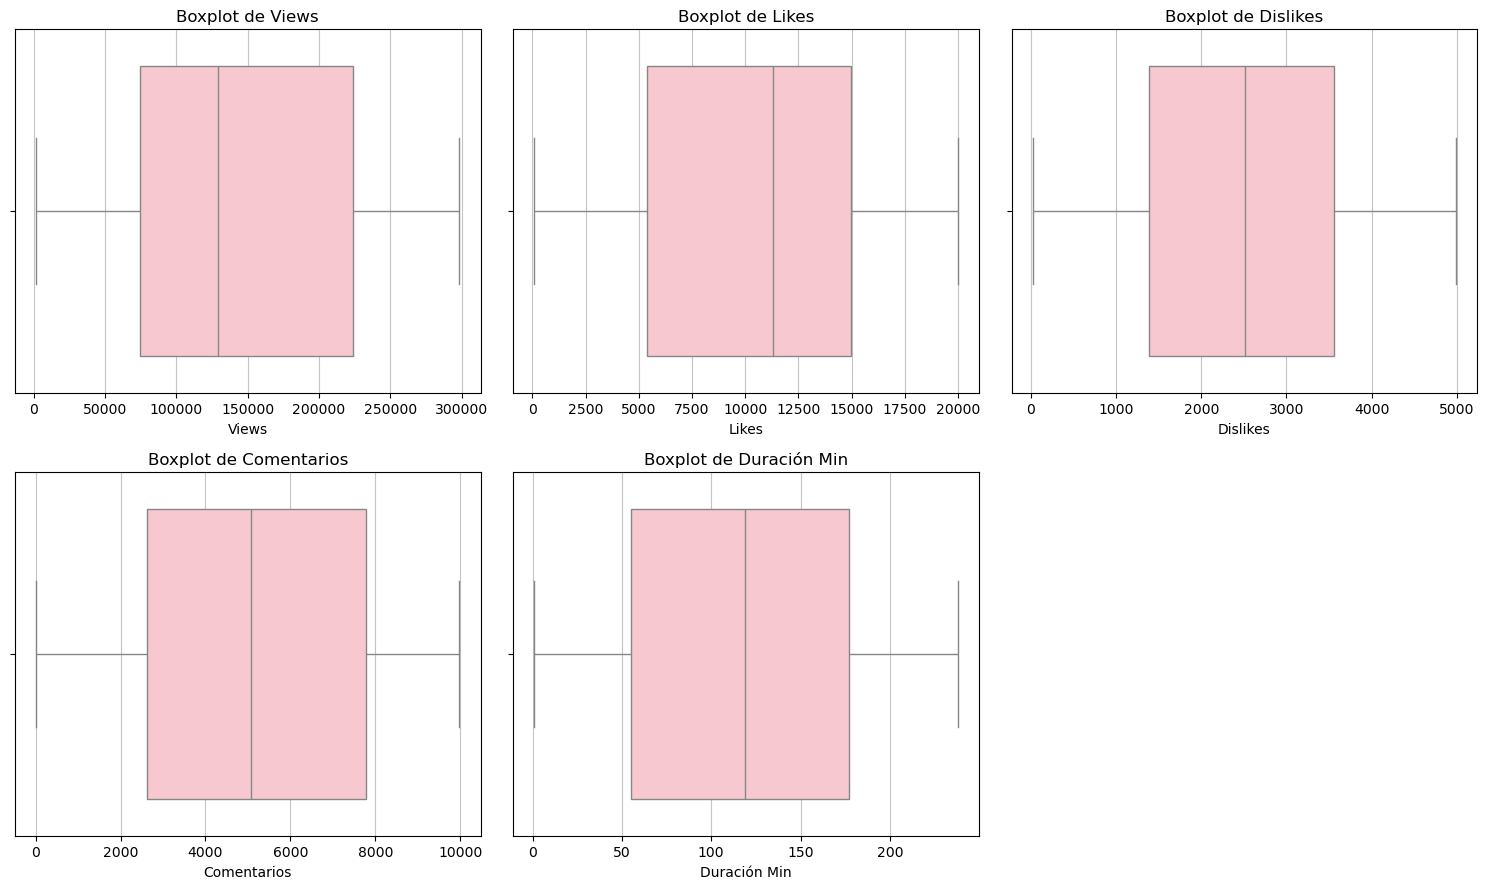

In [9]:
# Observar comportamiento cuartil final de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_copy[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

### **CORRELACIÓN NUMÉRICA**

La **correlación numérica** es una medida estadística que **indica la fuerza y dirección de la relación lineal entre dos o más variables numéricas**. Puede utilizar el coeficiente de correlación de Pearson (el más común) para determinar la dirección (positiva, negativa, nula).

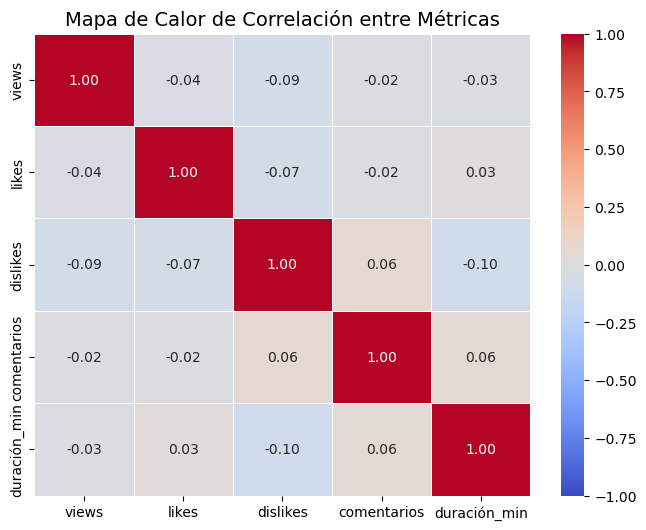

In [10]:
# Realizar matriz de correlación

corr_matrix = df_copy[['views', 'likes', 'dislikes', 'comentarios', 'duración_min']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Mapa de Calor de Correlación entre Métricas', fontsize=14)
plt.show()

# Los coeficientes de las intersecciones convergen en 0, no hay correlación

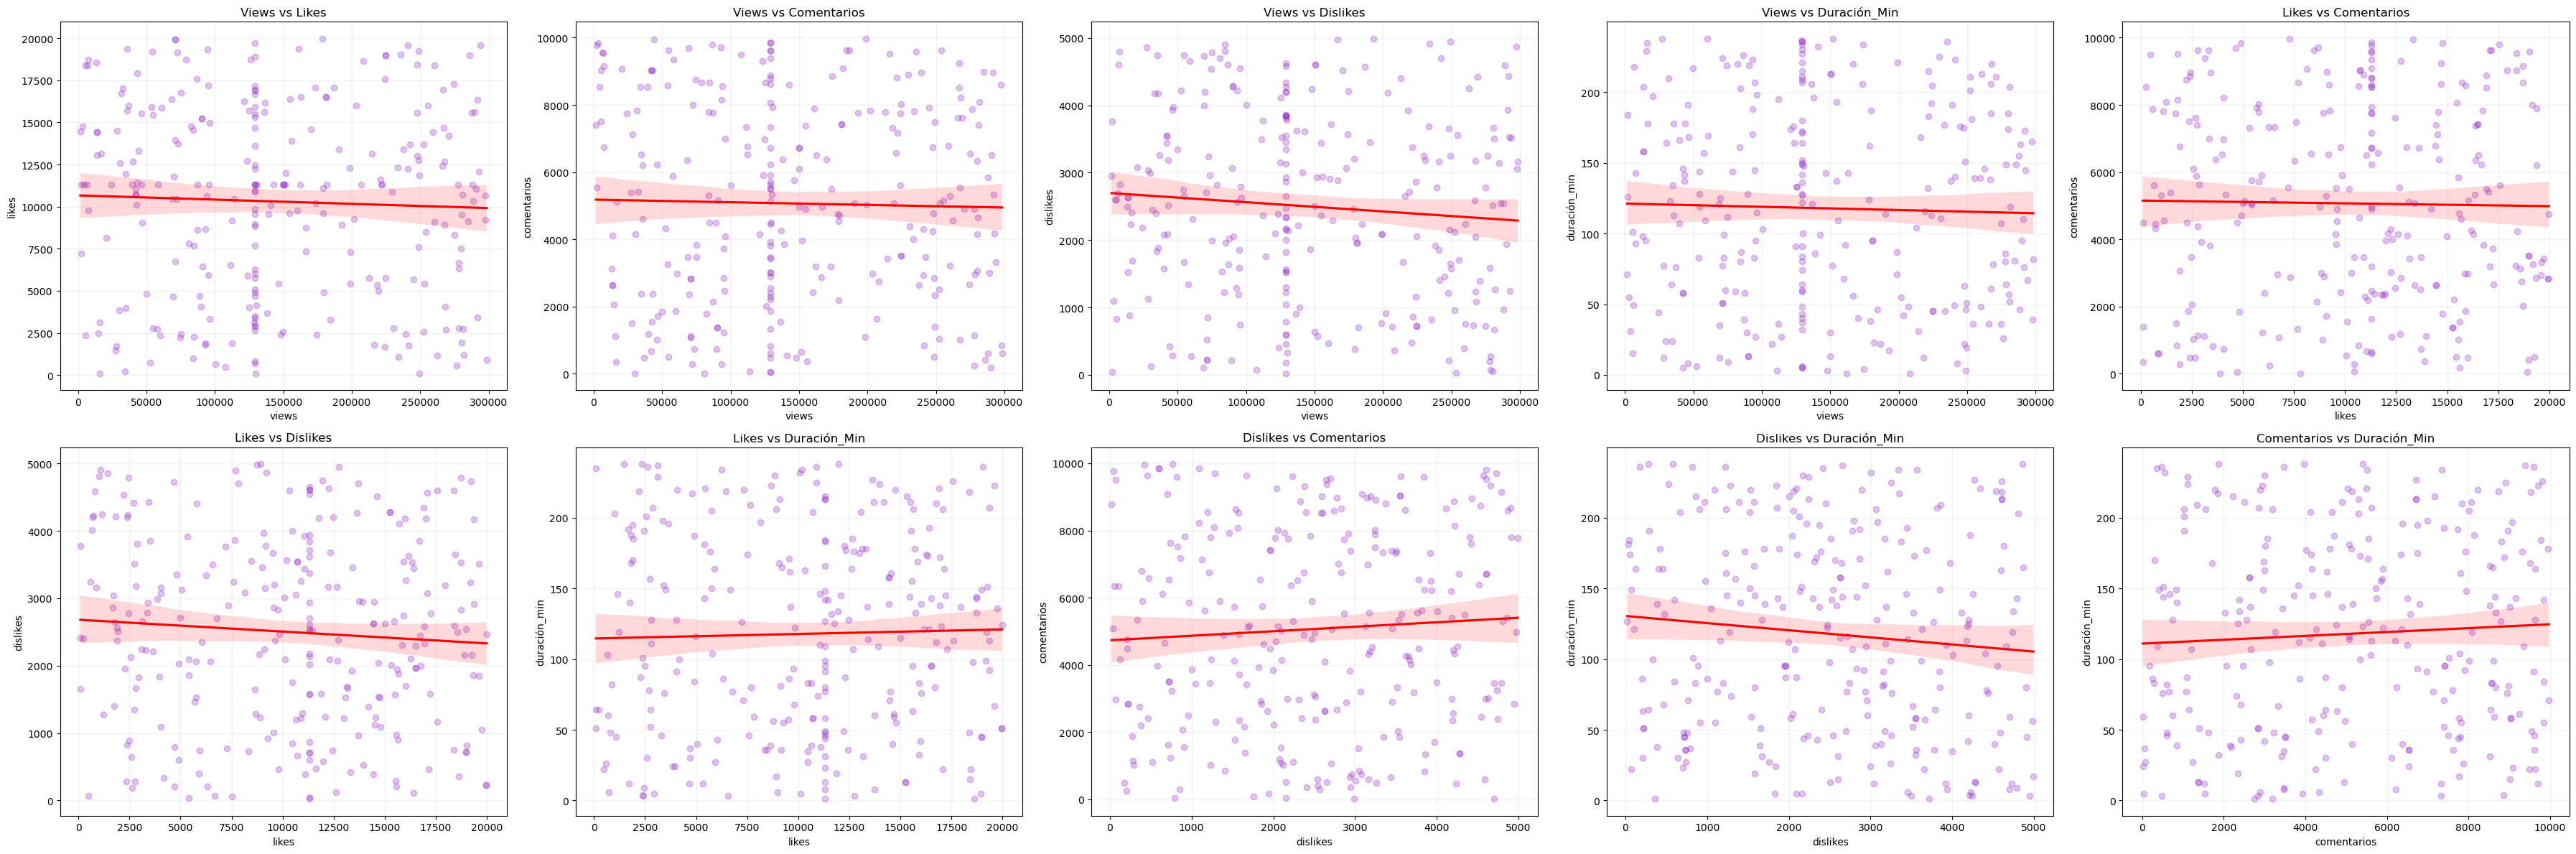

In [11]:
# Realizar correlaciones divididas

metricas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(36, 12))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Pares de comparación por
comparaciones = [
    ('views', 'likes'), ('views', 'comentarios'), ('views', 'dislikes'),
    ('views', 'duración_min'), ('likes', 'comentarios'), ('likes', 'dislikes'),
    ('likes', 'duración_min'), ('dislikes', 'comentarios'),
    ('dislikes', 'duración_min'), ('comentarios', 'duración_min')
]

for i, (col_x, col_y) in enumerate(comparaciones):
    sns.regplot(ax=axes[i], data=df_copy, x=col_x, y=col_y,
                scatter_kws={'alpha':0.3, 'color':'darkorchid'},
                line_kws={'color':'red'})
    axes[i].set_title(f'{col_x.title()} vs {col_y.title()}')
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Al no haber correlaciones, los datos se muestran dispersos

#### **COMPARACIÓN POR CATEGÓRICA**

La **comparación por categórica** implica analizar cómo las variables numéricas se comportan o distribuyen a través de diferentes grupos o categorías. Este tipo de análisis es fundamental para entender: **distribuciones, tendencias y relaciones**

Para visualizar estas comparaciones, son muy útiles los **gráficos de barras**, donde se pueden mostrar las cantidades o promedios de una variable numérica para cada categoría, o los **diagramas de caja (boxplots)**, que revelan la distribución completa de los datos dentro de cada grupo, incluyendo la mediana, cuartiles y posibles valores atípicos.

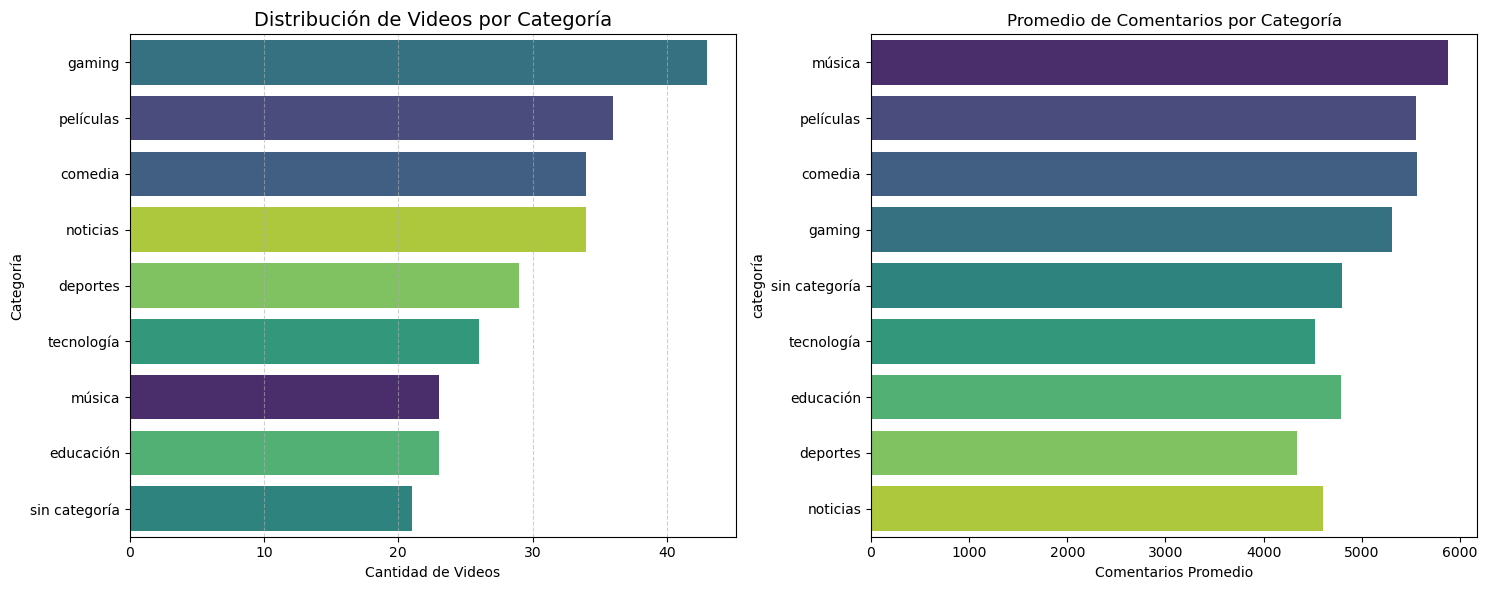

In [12]:
# Realizar gráficos de barras divididas

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
orden = df_copy['categoría'].value_counts().index # Ordenar de mayor a menor
sns.countplot(data=df_copy, y='categoría', order=orden, palette='viridis', hue='categoría', legend=False)
plt.title('Distribución de Videos por Categoría', fontsize=14)
plt.xlabel('Cantidad de Videos')
plt.ylabel('Categoría')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.barplot(data=df_copy, x='comentarios', y='categoría',
            estimator='mean', palette='viridis', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Comentarios por Categoría')
plt.xlabel('Comentarios Promedio')

plt.tight_layout()
plt.show()

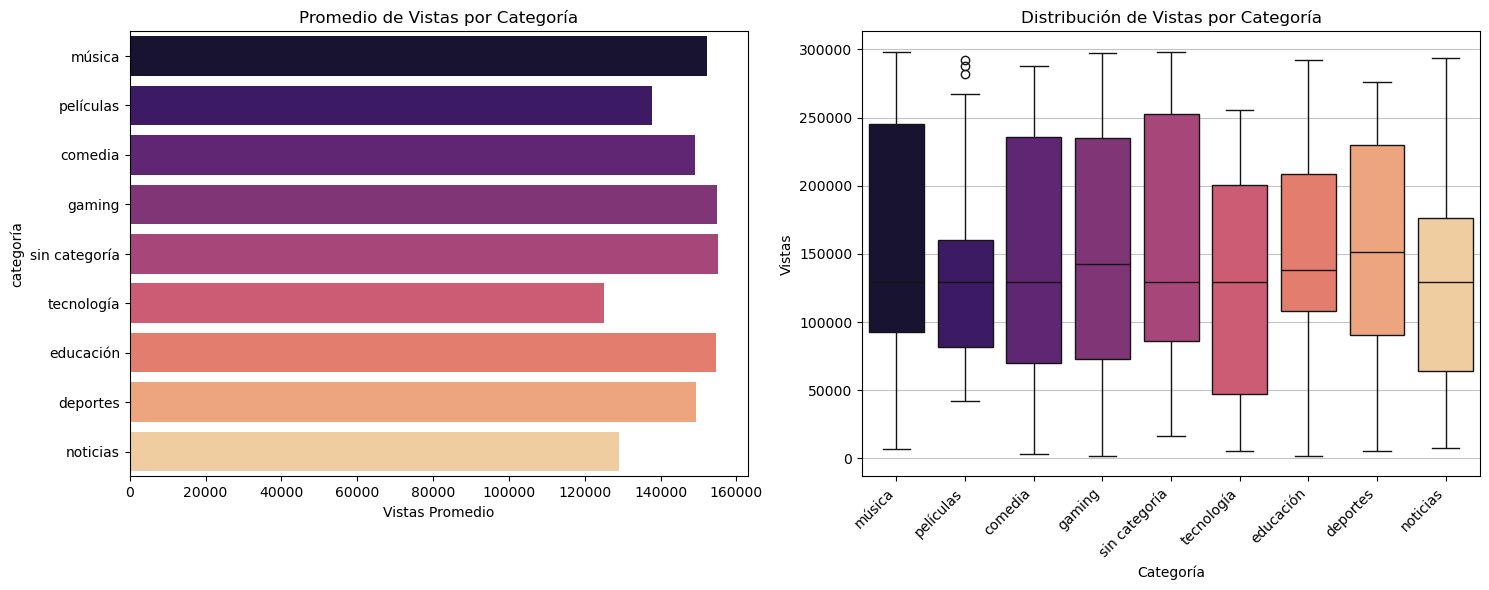

In [13]:
# Realizar gráfico de barras y caja divididos

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_copy, x='views', y='categoría',
            estimator='mean', palette='magma', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Vistas por Categoría')
plt.xlabel('Vistas Promedio')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_copy, x='categoría', y='views', palette='magma', hue='categoría', legend=False)
plt.title('Distribución de Vistas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Vistas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## **NARRATIVA VISUAL**

La **visualización narrativa** es la fusión estratégica entre la **claridad de los gráficos** y el **impacto del storytelling para comunicar mensajes** memorables. No se limita a exponer cifras, sino que construye un relato donde los datos actúan como evidencia para guiar a la audiencia hacia una conclusión clara.

Al conectar puntos de datos con una estructura narrativa, se logra captar la atención emocional y lógica del espectador. Esta técnica transforma estadísticas frías en una historia coherente, facilitando la comprensión de tendencias complejas y asegurando que los hallazgos clave impulsen una toma de decisiones informada.

### **PROPORCIÓN DE DATOS A MOSTRAR**

In [14]:
# Definir variables para la agrupación

categoria = lambda x: 'Sin Categoría' if x == 'sin categoría' else 'Con Categoría'
df_yt['agrupacion_cat'] = df_yt['categoría'].apply(categoria)
pie_data = df_yt['agrupacion_cat'].value_counts()

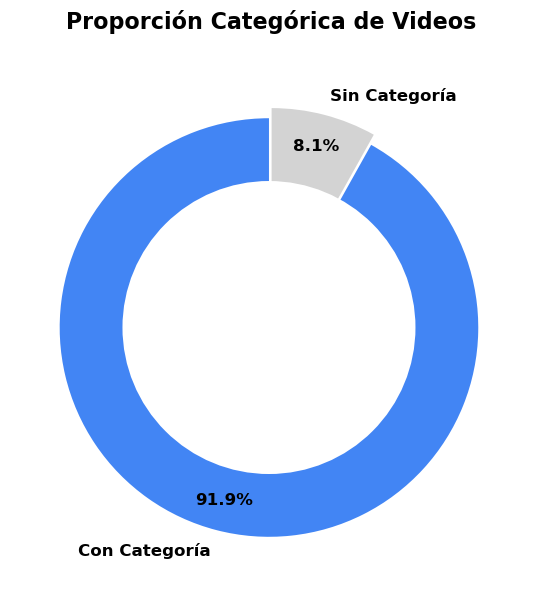

In [15]:
# Realizar gráfico de dona

colors_pie = ['#4285F4', '#D3D3D3'] # Azul = "Con Categoría", Gris = "Sin Categoría"
explode_val = 0.05 # Valor de separación

# Gráfico de pastel

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(pie_data,
                                   labels=pie_data.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors_pie,
                                   textprops={'fontsize': 12, 'fontweight': 'bold'},
                                   pctdistance=0.85, # Mueve el porcentaje hacia afuera
                                   explode=(explode_val, 0)) # Resalta ligeramente la porción principal

# Círculo blanco central (estilo moderno)

theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center_angle = np.deg2rad((theta1 + theta2) / 2) # Obtención el ángulo medio

cx = explode_val * np.cos(center_angle) # Se Calcula nueva posición con trigonometría
cy = explode_val * np.sin(center_angle)

centre_circle = plt.Circle((cx, cy), 0.70, fc='white') # Se dibuja el circulo
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción Categórica de Videos', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### **DISTRIBUCIÓN DE VÍDEOS POR CATEGORÍA**

In [16]:
# Definir variables

df_filtrado = df_yt[df_yt['categoría'] != 'sin categoría']
counts = df_filtrado['categoría'].value_counts()
order = counts.index
values = counts.values

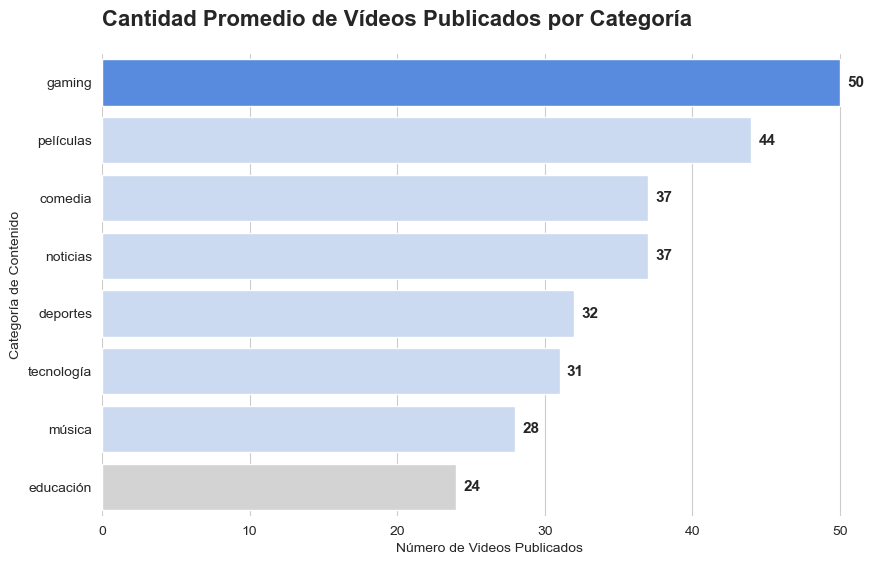

In [17]:
# Realizar gráfico de barras

colors = ['#4285F4' if v == values.max() else '#D3D3D3' if v == values.min() else '#C6D9F7' for v in values]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=values, y=order, palette=colors, hue=order, legend=False)

for p in ax.patches: # Etiquetas de datos
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Cantidad Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Videos Publicados')
plt.ylabel('Categoría de Contenido')
sns.despine(left=True, bottom=True)
plt.show()

### **PROMEDIO DE VISTAS POR CATEGORÍA**

In [18]:
# Definir variables

vistas_mean = df_yt.groupby('categoría')['views'].mean().sort_values(ascending=False)
colors_vistas = ['#4285F4' if v == vistas_mean.max() else '#D3D3D3' if v == vistas_mean.min() else '#C6D9F7' for v in vistas_mean]

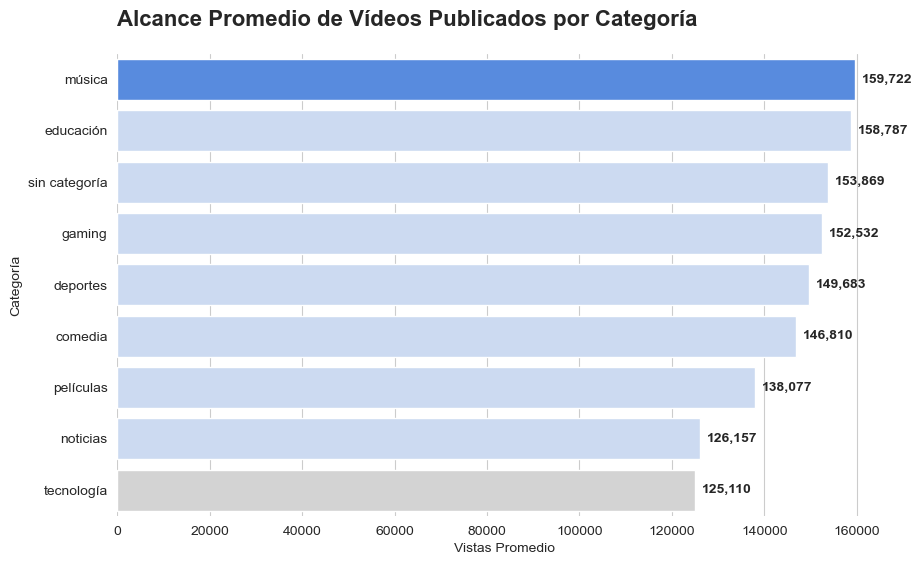

In [19]:
# Realizar gráfico de barras

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax1 = sns.barplot(x=vistas_mean.values, y=vistas_mean.index, palette=colors_vistas, hue=vistas_mean.index, legend=False)

for p in ax1.patches: # Etiquetas y estética
    ax1.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Alcance Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vistas Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()

### **PROMEDIO DE COMENTARIOS POR CATEGORÍA**

In [20]:
# Definir variables

coments_mean = df_yt.groupby('categoría')['comentarios'].mean().sort_values(ascending=False)
colors_coments = ['#4285F4' if v == coments_mean.max() else '#D3D3D3' if v == coments_mean.min() else '#C6D9F7' for v in coments_mean]

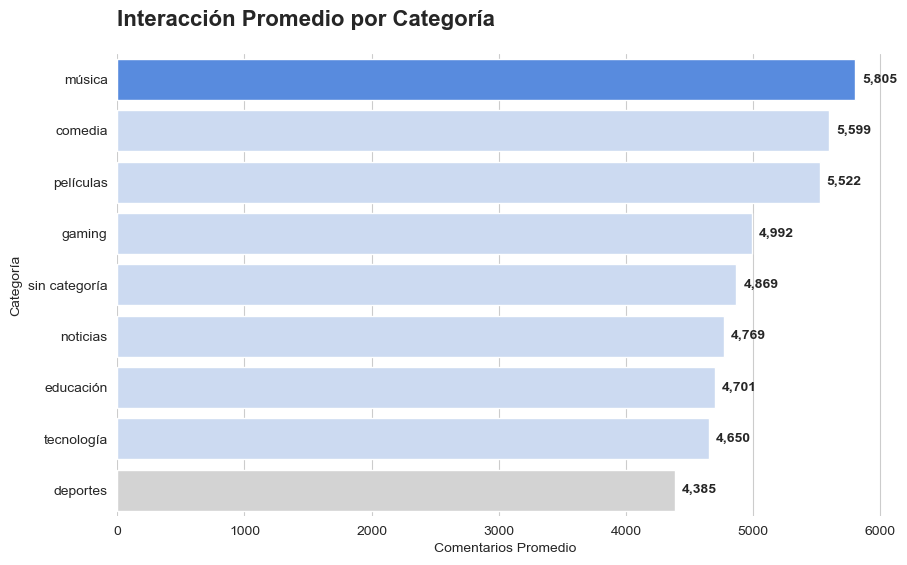

In [21]:
# Realizar gráfico de barras

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax2 = sns.barplot(x=coments_mean.values, y=coments_mean.index, palette=colors_coments, hue=coments_mean.index, legend=False)

for p in ax2.patches: # Etiquetas y estética
    ax2.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Interacción Promedio por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Comentarios Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()

## **CHALLENGE: EXPLORACIÓN DE DATOS AIRBNB CDMX**

Una vez visto el ***Hands - On: Exploración de datos***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1HKCV2jFnumpJ1YNFI5cn6wgT2tEiKKfK/view?usp=drive_link)

Dentro de la siguiente dinámica, **se realizará un análisis exploratorio profundo sobre el catálogo de alojamientos de Airbnb en la Ciudad de México** para detectar patrones de comportamiento, valores atípicos y relaciones entre variables. Se hará uso de **herramientas estadísticas, técnicas de detección de outliers y narrativa visual** a través del dataset **"airbnb_clean"**.

Donde los análisis a realizar son:

* **Detección y tratamiento de valores atípicos mediante el rango intercuartílico**.
* **Identificación de relaciones lineales entre variables numéricas**.
* **Comunicación de hallazgos a través de narrativa visual por categoría**.

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importaciones y análisis de resumen estadístico:**

* Carga las bibliotecas de Pandas, Numpy, Seaborn y Matplotlib.pyplot.
* Carga el archivo *airbnb_clean.csv*.
* Obtén el resumen estadístico de los datos.

In [22]:
# Importar librerías

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
# Importar datos

df = pd.read_csv('airbnb_clean.csv')
df

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,35797,Villa Dante,153786,Dici,Cuajimalpa de Morelos,19.382830,-99.271780,Entire home/apt,3673.0,1,0,Never reviewed,0.00,1,363,0
1,44616,Condesa Haus,196253,Fernando,Cuauhtémoc,19.411620,-99.177940,Entire home/apt,18000.0,1,65,2025-01-01,0.38,9,360,1
2,56074,Great space in historical San Rafael,265650,Maris,Cuauhtémoc,19.439770,-99.156050,Entire home/apt,591.0,15,84,2025-02-27,0.48,1,333,1
3,67703,"2 bedroom apt. deco bldg, Condesa",334451,Nicholas,Cuauhtémoc,19.411520,-99.168570,Entire home/apt,1039.0,2,50,2024-10-30,0.30,2,252,1
4,70644,Beautiful light Studio Coyoacan- full equipped !,212109,Trisha,Coyoacán,19.354480,-99.162170,Entire home/apt,1039.0,3,134,2025-08-18,0.81,3,234,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27046,1518356968266486778,Suite Frida,674644167,Heyliana,Venustiano Carranza,19.442240,-99.113440,Private room,1096.0,1,0,Never reviewed,0.00,5,365,0
27047,1518388105556721163,Habitación a un costado de Ciudad Universitaria,222854336,Marco Antonio,Coyoacán,19.308017,-99.168158,Private room,260.0,1,0,Never reviewed,0.00,1,365,0
27048,1518433354720281854,Espacioso departamento en Anzures,470800231,Hector Fernando,Miguel Hidalgo,19.434460,-99.174010,Entire home/apt,996.0,1,0,Never reviewed,0.00,20,365,0
27049,1518462568893975567,Casa Roma Baja 05,710857718,Camila,Cuauhtémoc,19.406435,-99.160934,Entire home/apt,458.0,1,0,Never reviewed,0.00,7,363,0


In [24]:
# Ver resumen estadístico

# Columnas numéricas representativas del análisis
columnas_numericas = ['price', 'minimum_nights', 'number_of_reviews',
                      'reviews_per_month', 'availability_365', 'number_of_reviews_ltm']
df[columnas_numericas].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,number_of_reviews_ltm
count,27051.000000,27051.000000,27051.000000,27051.000000,27051.000000,27051.000000
mean,1695.489483,4.580866,53.777679,1.621652,232.686333,15.691028
std,12352.097771,24.784605,85.143043,2.219818,122.270858,23.615517
min,61.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,700.000000,1.000000,4.000000,0.210000,140.000000,0.000000
50%,1039.000000,2.000000,21.000000,1.000000,269.000000,7.000000
75%,1484.000000,2.000000,69.000000,2.370000,341.000000,23.000000
max,900000.000000,1125.000000,1434.000000,119.460000,365.000000,665.000000


**2. Análisis de distribución y filtrado de outliers:**

* Genera un histograma y diagrama de caja sobre la columna `price`.
* Calcula la cantidad de registros con los que cuenta el dataframe.
* Calcula el rango intercuartílico y filtra el dataframe con los registros dentro de los límites.
* Calcula la cantidad y proporción de registros finales y grafica su diagrama de caja.

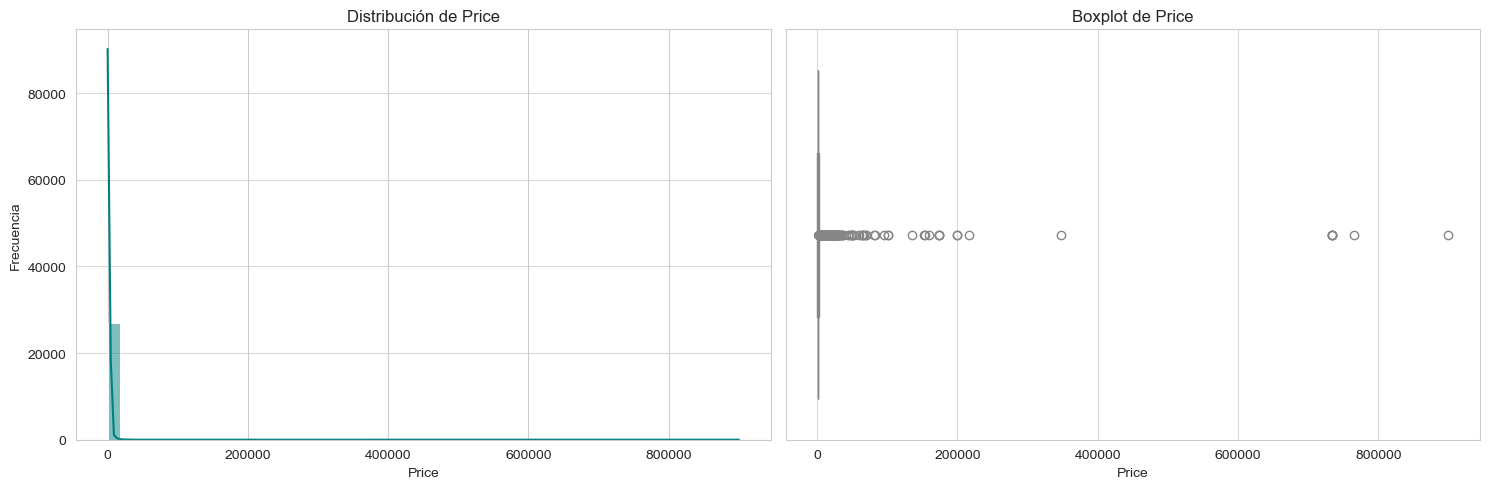

In [25]:
# Observar distribución y comportamiento cuartil de los datos

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=50, kde=True, color='teal')
plt.title('Distribución de Price')
plt.xlabel('Price')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
sns.boxplot(x=df['price'], color='pink')
plt.title('Boxplot de Price')
plt.xlabel('Price')
plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

# La distribución está fuertemente sesgada a la derecha por valores atípicos de precio

In [26]:
# Ver cantidad de registros iniciales

print(f"Cantidad de datos iniciales: {len(df)}")

Cantidad de datos iniciales: 27051


In [27]:
# Calculo del IQR

df_copy = df.copy() # Preservar el dataset original

Q1 = df_copy['price'].quantile(0.25)  # Primer cuartil
Q3 = df_copy['price'].quantile(0.75)  # Tercer cuartil
IQR = Q3 - Q1                          # Rango Intercuartílico

lim_inf_iqr = Q1 - 1.5 * IQR  # Límite inferior
lim_sup_iqr = Q3 + 1.5 * IQR  # Límite superior

# Filtro de los datos dentro de los límites
df_copy = df_copy[(df_copy['price'] >= lim_inf_iqr) & (df_copy['price'] <= lim_sup_iqr)]

print(f"Q1 = {Q1} | Q3 = {Q3} | IQR = {IQR}")
print(f"Límites IQR: [{lim_inf_iqr}, {lim_sup_iqr}]")

Q1 = 700.0 | Q3 = 1484.0 | IQR = 784.0
Límites IQR: [-476.0, 2660.0]


In [28]:
# Ver cantidad y proporción con la cantidad inicial

prop_cant_datos = round((len(df_copy) / len(df)) * 100, 2)

print(f"Cantidad de datos finales: {len(df_copy)}")
print(f"Los datos finales representan el {prop_cant_datos}% de los datos iniciales")

Cantidad de datos finales: 24741
Los datos finales representan el 91.46% de los datos iniciales


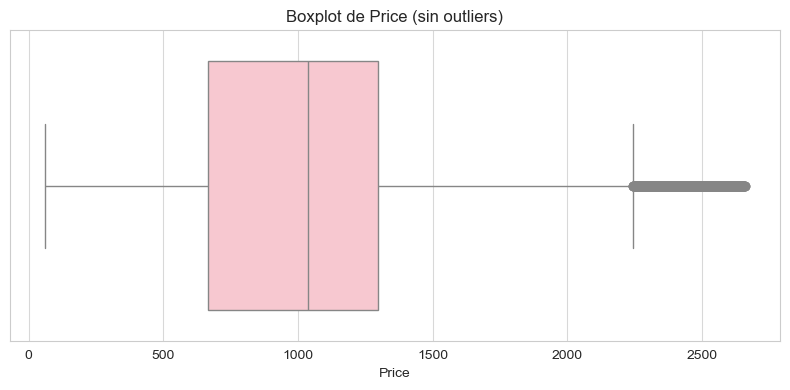

In [29]:
# Observar comportamiento cuartil final de los datos

plt.figure(figsize=(8, 4))
sns.boxplot(x=df_copy['price'], color='pink')
plt.title('Boxplot de Price (sin outliers)')
plt.xlabel('Price')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

**3. Análisis de correlaciones:**

* Genera una matriz de correlación sobre las columnas numéricas del dataframe.
* Selecciona las variables numéricas más representativas.
* Realiza correlaciones divididas por categoría segmentadas por la columna `room_type`.

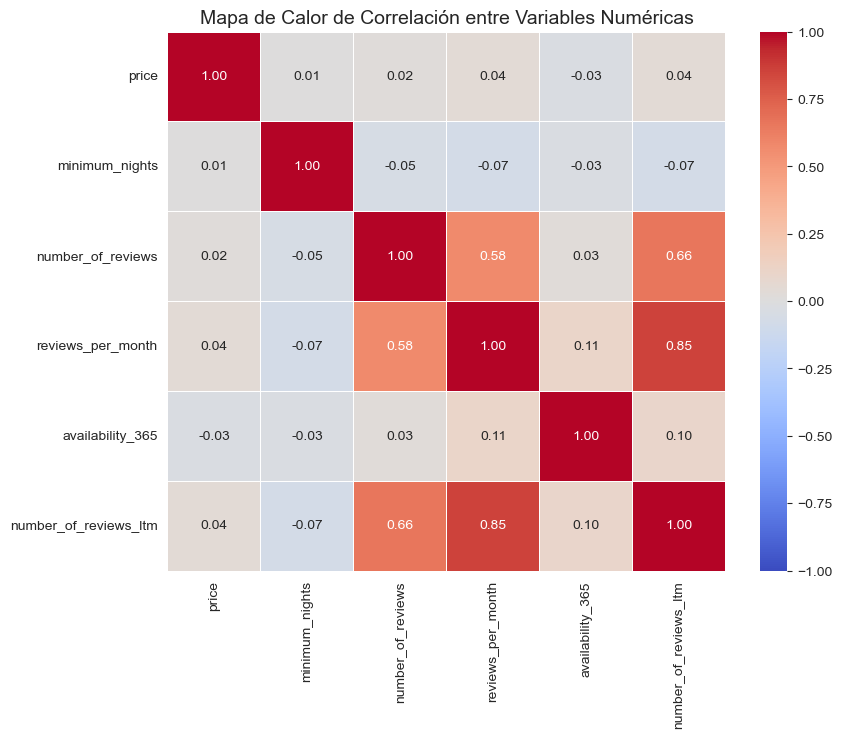

In [30]:
# Realizar matriz de correlación

corr_matrix = df_copy[columnas_numericas].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlación entre Variables Numéricas', fontsize=14)
plt.show()

# Las correlaciones más fuertes se dan entre las variables de reseñas

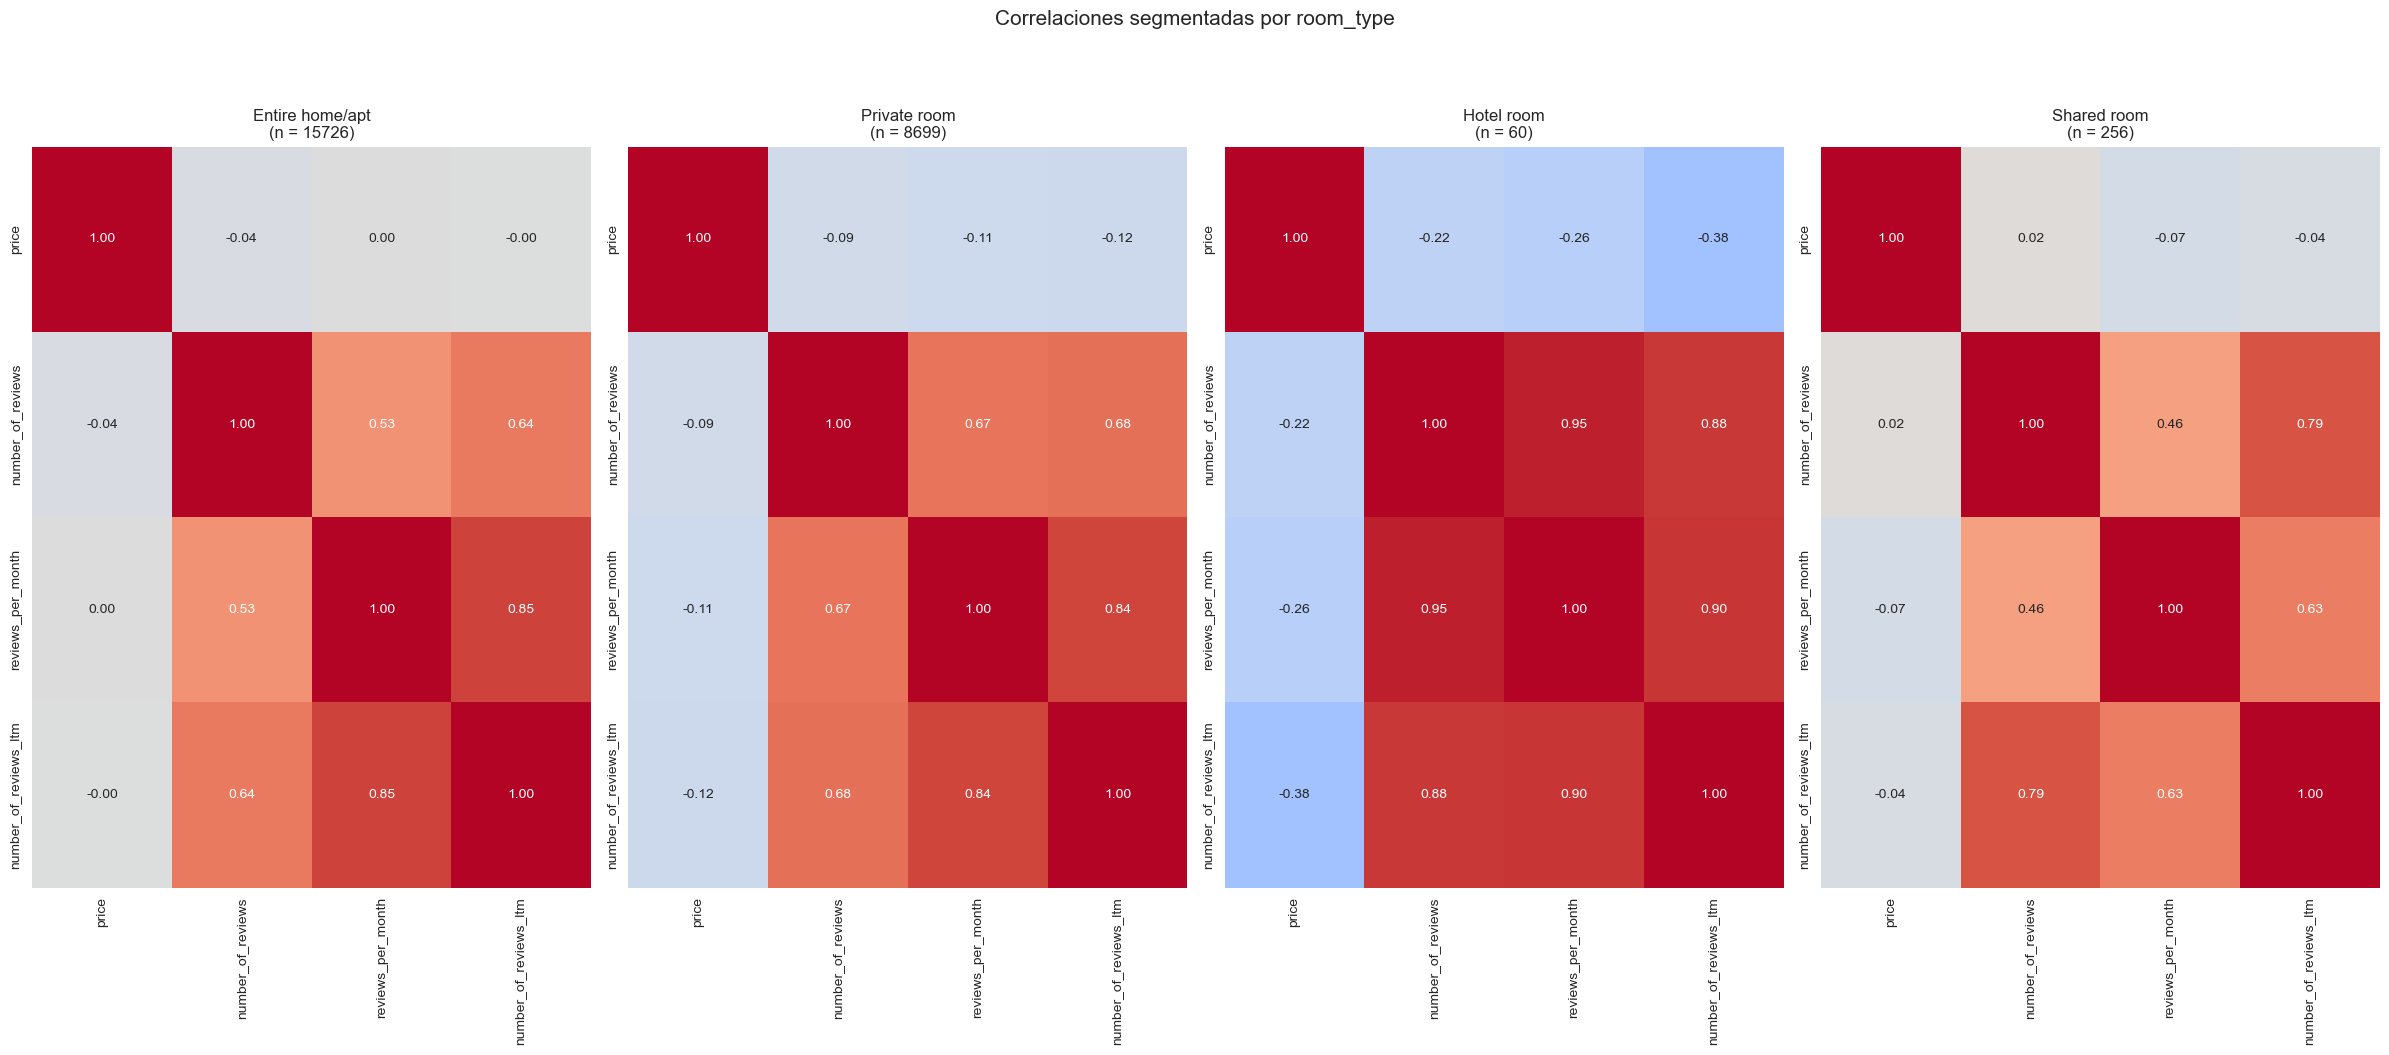

In [43]:
# Realizar correlaciones divididas

# Variables más representativas para segmentar por tipo de habitación
metricas = ['price', 'number_of_reviews', 'reviews_per_month', 'number_of_reviews_ltm']
room_types = df_copy['room_type'].unique()

fig, axes = plt.subplots(1, len(room_types), figsize=(24, 10))

for ax, rt in zip(axes, room_types):
    sub = df_copy[df_copy['room_type'] == rt]
    sns.heatmap(sub[metricas].corr(), annot=True, cmap='coolwarm', fmt=".2f",
                vmin=-1, vmax=1, cbar=False, ax=ax)
    ax.set_title(f'{rt}\n(n = {len(sub)})')

plt.suptitle('Correlaciones segmentadas por room_type', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

**4. Regresión lineal simple:**

* Define como variable independiente `reviews_per_month` y como dependiente `number_of_reviews_ltm`.
* Calcula los coeficientes para determinar la ecuación del modelo de regresión lineal simple.
* Ajusta el modelo de regresión lineal con descenso de gradiente y determina la nueva ecuación.
* Visualizar el modelo de regresión lineal ajustada y la curva de perdidas.
* Calcula la reducción del error desde la primera hasta la última época.


In [32]:
# Cálculo de la regresión lineal simple

# Variable independiente (X) y dependiente (y)
X = df_copy['reviews_per_month'].values.astype(float)
y = df_copy['number_of_reviews_ltm'].values.astype(float)

# Coeficientes por el método de mínimos cuadrados (forma cerrada)
x_mean = X.mean()
y_mean = y.mean()

m = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean) ** 2)  # Pendiente
b = y_mean - m * x_mean                                              # Intercepto

print(f"Pendiente (m): {m:.4f}")
print(f"Intercepto (b): {b:.4f}")
print(f"Ecuación inicial: y = {m:.4f}x + {b:.4f}")

Pendiente (m): 9.0574
Intercepto (b): 1.0101
Ecuación inicial: y = 9.0574x + 1.0101


In [33]:
# Calculo del descenso de gradiente

# Hiperparámetros
lr = 0.01        # Tasa de aprendizaje
epochs = 1000    # Número de épocas
n = len(X)

# Inicialización de parámetros
m_gd, b_gd = 0.0, 0.0
perdidas = []  # Historial del error (MSE) por época

for epoca in range(epochs):
    y_pred = m_gd * X + b_gd          # Predicción
    error = y_pred - y               # Residuos
    perdida = np.mean(error ** 2)    # Función de pérdida (MSE)
    perdidas.append(perdida)

    # Gradientes
    dm = (2 / n) * np.dot(error, X)
    db = (2 / n) * np.sum(error)

    # Actualización de parámetros
    m_gd -= lr * dm
    b_gd -= lr * db

print(f"Pendiente ajustada (m): {m_gd:.4f}")
print(f"Intercepto ajustado (b): {b_gd:.4f}")
print(f"Ecuación ajustada: y = {m_gd:.4f}x + {b_gd:.4f}")

Pendiente ajustada (m): 9.0574
Intercepto ajustado (b): 1.0101
Ecuación ajustada: y = 9.0574x + 1.0101


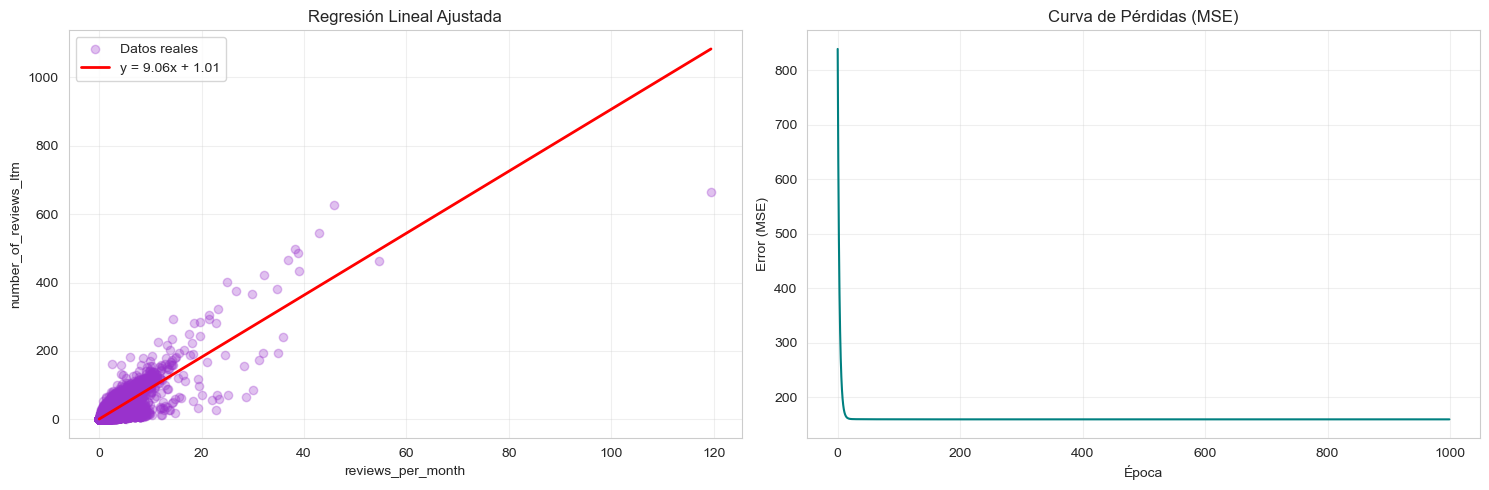

In [34]:
# Visualizar regresión lineal y perdidas

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Modelo de regresión lineal ajustado
axes[0].scatter(X, y, alpha=0.3, color='darkorchid', label='Datos reales')
x_line = np.linspace(X.min(), X.max(), 100)
axes[0].plot(x_line, m_gd * x_line + b_gd, color='red', linewidth=2,
             label=f'y = {m_gd:.2f}x + {b_gd:.2f}')
axes[0].set_title('Regresión Lineal Ajustada')
axes[0].set_xlabel('reviews_per_month')
axes[0].set_ylabel('number_of_reviews_ltm')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Curva de pérdidas
axes[1].plot(range(epochs), perdidas, color='teal')
axes[1].set_title('Curva de Pérdidas (MSE)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Error (MSE)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# Registro final de perdida

reduccion = perdidas[0] - perdidas[-1]
reduccion_pct = round((reduccion / perdidas[0]) * 100, 2)

print(f"Pérdida inicial (época 1):     {perdidas[0]:.2f}")
print(f"Pérdida final (época {epochs}):   {perdidas[-1]:.2f}")
print(f"Reducción del error: {reduccion:.2f} ({reduccion_pct}%)")

Pérdida inicial (época 1):     839.45
Pérdida final (época 1000):   159.46
Reducción del error: 679.99 (81.0%)


**5. Comparación por categoría:**

* Utiliza un gráfico de barras para mostrar el precio promedio por tipo de habitación.
* Utiliza un diagrama de caja para visualizar la distribución del precio por tipo de habitación.
* Agrupa el dataframe por la columna `room_type` y calcula el conteo de alojamientos.
* Utiliza un gráfico de dona que muestre el porcentaje de cada categoría.

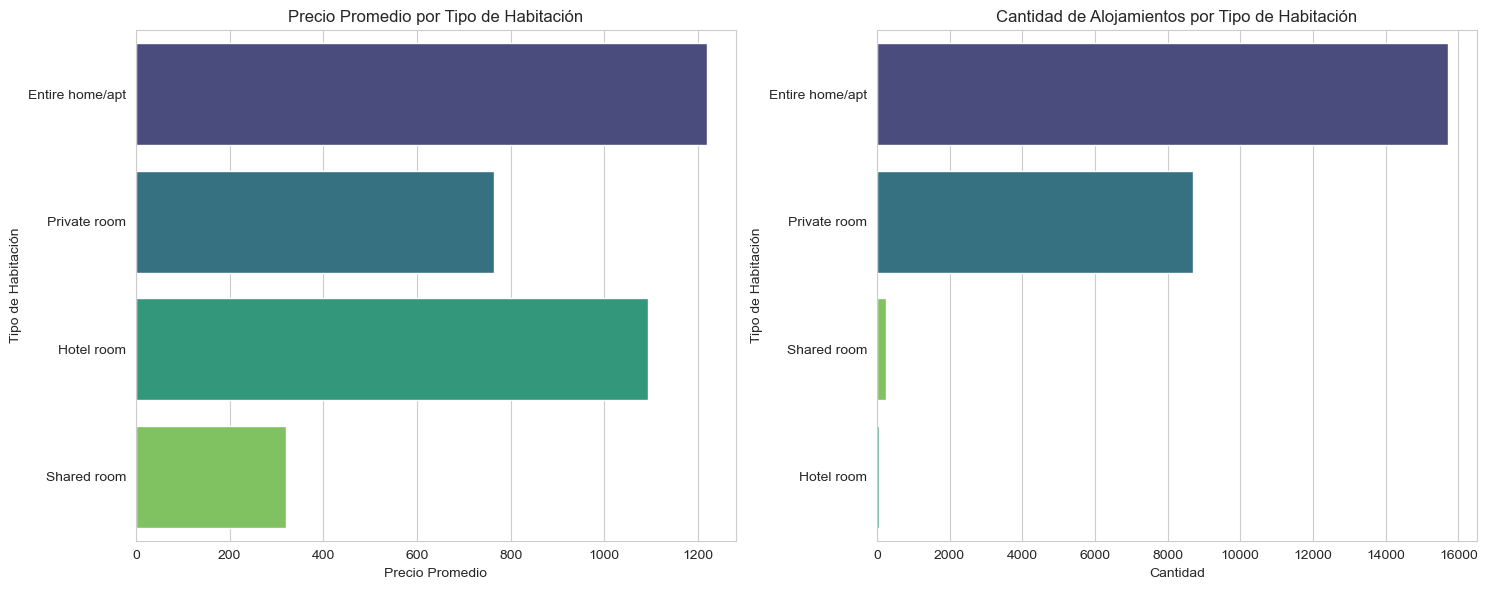

In [36]:
# Realizar gráficos de barras divididas

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_copy, x='price', y='room_type',
            estimator='mean', errorbar=None, palette='viridis', hue='room_type', legend=False)
plt.title('Precio Promedio por Tipo de Habitación')
plt.xlabel('Precio Promedio')
plt.ylabel('Tipo de Habitación')

plt.subplot(1, 2, 2)
orden = df_copy['room_type'].value_counts().index
sns.countplot(data=df_copy, y='room_type', order=orden, palette='viridis', hue='room_type', legend=False)
plt.title('Cantidad de Alojamientos por Tipo de Habitación')
plt.xlabel('Cantidad')
plt.ylabel('Tipo de Habitación')

plt.tight_layout()
plt.show()

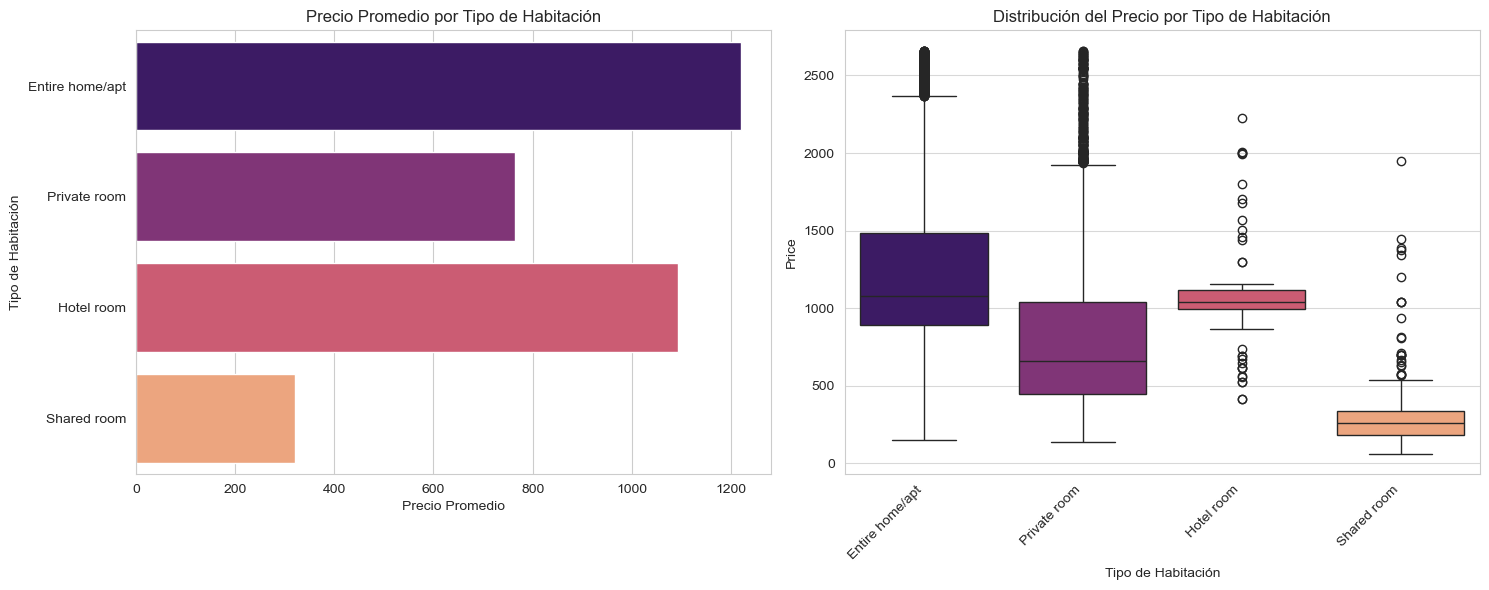

In [37]:
# Realizar gráfico de barras y caja divididos

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_copy, x='price', y='room_type',
            estimator='mean', errorbar=None, palette='magma', hue='room_type', legend=False)
plt.title('Precio Promedio por Tipo de Habitación')
plt.xlabel('Precio Promedio')
plt.ylabel('Tipo de Habitación')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_copy, x='room_type', y='price', palette='magma', hue='room_type', legend=False)
plt.title('Distribución del Precio por Tipo de Habitación')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

In [38]:
# Definir variables para la agrupación

# Agrupar por tipo de habitación y contar alojamientos
pie_data = df_copy.groupby('room_type').size().sort_values(ascending=False)
print(pie_data)

room_type
Entire home/apt    15726
Private room        8699
Shared room          256
Hotel room            60
dtype: int64


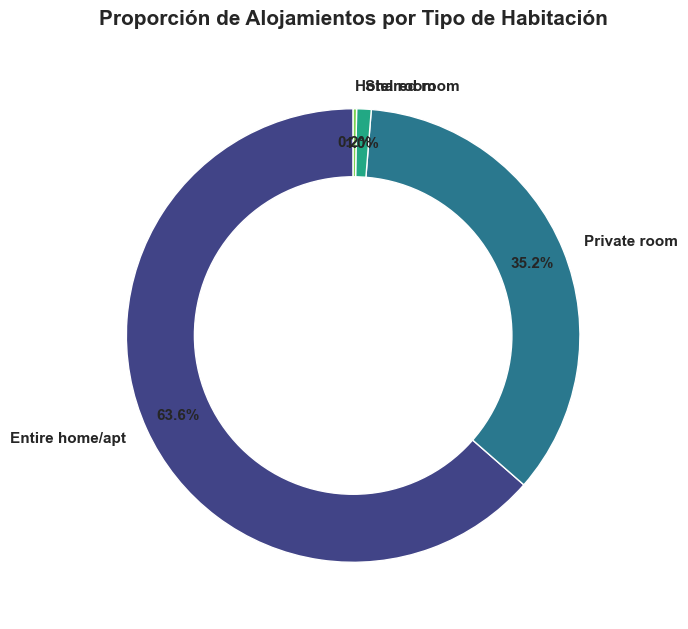

In [39]:
# Realizar gráfico de dona

colors_pie = sns.color_palette('viridis', len(pie_data))

plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(pie_data,
                                   labels=pie_data.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors_pie,
                                   textprops={'fontsize': 11, 'fontweight': 'bold'},
                                   pctdistance=0.85)

# Círculo blanco central (estilo dona)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gcf().gca().add_artist(centre_circle)

plt.title('Proporción de Alojamientos por Tipo de Habitación', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**6. Narrativa visual:**

* Utiliza un gráfico de barras horizontales para mostrar el conteo de alojamientos por alcaldía.
* Utiliza un gráfico de barras horizontales para mostrar el precio promedio por alcaldía.
* Utiliza un gráfico de barras horizontales para mostrar el promedio de reseñas por alcaldía.

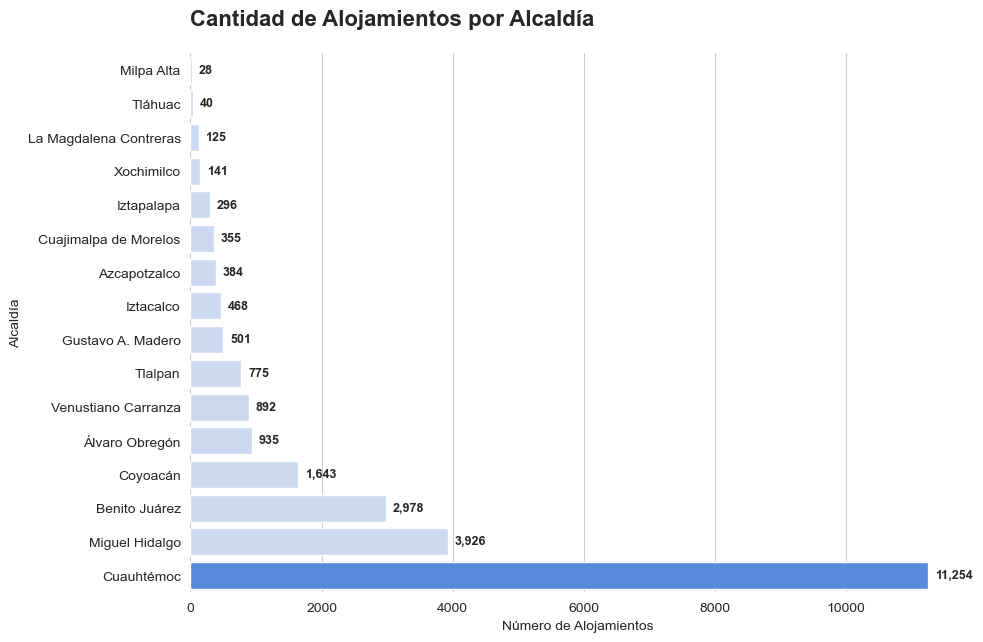

In [40]:
# Realizar gráfico de barras

# Conteo de alojamientos por alcaldía
conteo_alcaldia = df_copy['neighbourhood'].value_counts().sort_values(ascending=True)
colors = ['#4285F4' if v == conteo_alcaldia.max() else '#D3D3D3' if v == conteo_alcaldia.min() else '#C6D9F7' for v in conteo_alcaldia]

plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
ax = sns.barplot(x=conteo_alcaldia.values, y=conteo_alcaldia.index, palette=colors, hue=conteo_alcaldia.index, legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=9, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Cantidad de Alojamientos por Alcaldía', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Alojamientos')
plt.ylabel('Alcaldía')
sns.despine(left=True, bottom=True)
plt.show()

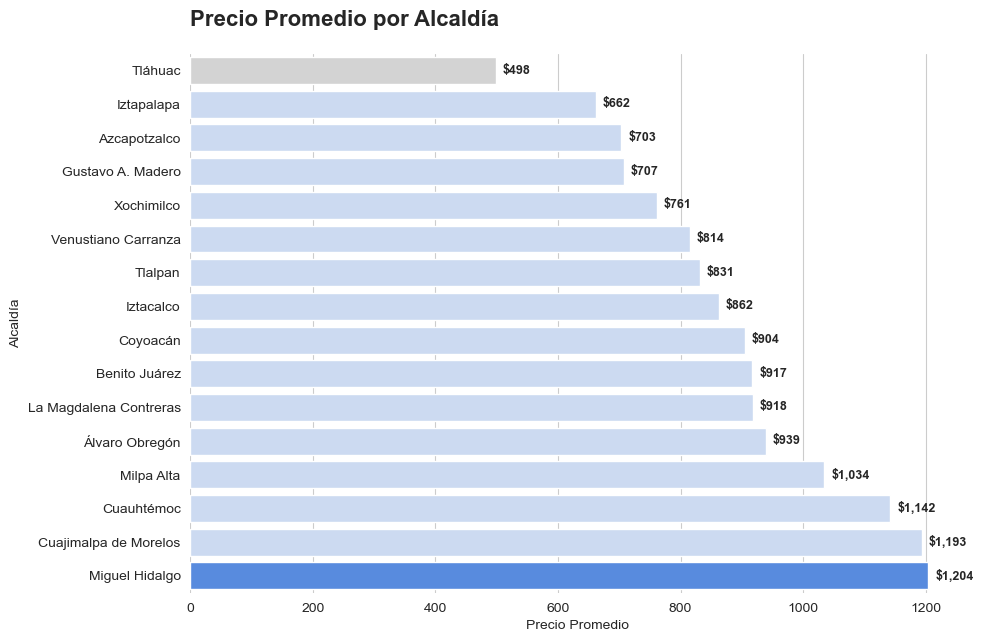

In [41]:
# Realizar gráfico de barras

# Precio promedio por alcaldía
precio_alcaldia = df_copy.groupby('neighbourhood')['price'].mean().sort_values(ascending=True)
colors = ['#4285F4' if v == precio_alcaldia.max() else '#D3D3D3' if v == precio_alcaldia.min() else '#C6D9F7' for v in precio_alcaldia]

plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
ax = sns.barplot(x=precio_alcaldia.values, y=precio_alcaldia.index, palette=colors, hue=precio_alcaldia.index, legend=False)

for p in ax.patches:
    ax.annotate(f'${int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=9, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Precio Promedio por Alcaldía', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Precio Promedio')
plt.ylabel('Alcaldía')
sns.despine(left=True, bottom=True)
plt.show()

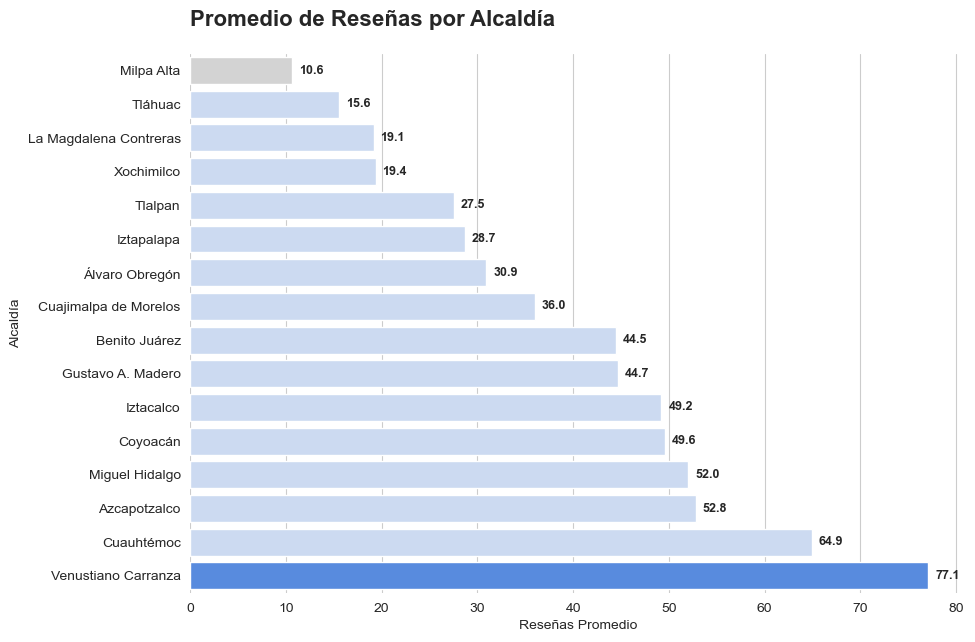

In [42]:
# Realizar gráfico de barras

# Promedio de reseñas por alcaldía
reviews_alcaldia = df_copy.groupby('neighbourhood')['number_of_reviews'].mean().sort_values(ascending=True)
colors = ['#4285F4' if v == reviews_alcaldia.max() else '#D3D3D3' if v == reviews_alcaldia.min() else '#C6D9F7' for v in reviews_alcaldia]

plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
ax = sns.barplot(x=reviews_alcaldia.values, y=reviews_alcaldia.index, palette=colors, hue=reviews_alcaldia.index, legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=9, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Promedio de Reseñas por Alcaldía', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Reseñas Promedio')
plt.ylabel('Alcaldía')
sns.despine(left=True, bottom=True)
plt.show()